In [41]:
import os
import pandas as pd
from sqlalchemy import create_engine
from dotenv import load_dotenv
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from nbt import nbt
import base64
import gzip
import io
import re

# Load the mysql database into memory

In [37]:
# 1. Manually find the .env file relative to this notebook
# '..' goes up to src, the second '..' goes up to the root
env_path = Path('../../.env')
load_dotenv(dotenv_path=env_path)

# 2. Now os.getenv will work
USER = os.getenv("MYSQL_USER")
PASSWORD = os.getenv("MYSQL_PASSWORD")
DATABASE = os.getenv("MYSQL_DATABASE")
HOST = "localhost" # Stay as localhost since it's host-to-container
PORT = "3306"

# 3. Create the engine and load
engine = create_engine(f"mysql+mysqlconnector://{USER}:{PASSWORD}@{HOST}:{PORT}/{DATABASE}")

df = pd.read_sql("SELECT * FROM auctions", engine)
print(df)

print(f"Success! Loaded {len(df)} rows.")

                           auction_uuid                       seller_uuid  \
0      000054592a8b4c8080c9cf24e0f3bfa2  d4e6bc1766644340bdeadab5a601320d   
1      000184372e7b4c338b0754c38e246c41  c09f19840cef4c5aaca596db26ab62f2   
2      000346a5056a4940977b4c8cb4da14d9  df5951ce13574eb1b94a3a5c16608295   
3      00037871872e45bca4e77c0955f5f737  824ad72f6e4f4fc48c67c9d0ca59a99c   
4      0006f91511fe451daa0813431a6c0654  7856b28658824089b0b6ee553cb8ed93   
...                                 ...                               ...   
18184  fff7664cdd89489f99a5b215c836bc6e  039ae7ed430c498d8e547ca74b5d906b   
18185  fff9c87db57d4d85a6efdcddcb6d3ff9  1ab216c3cc7d45cf98f85ce43c22c063   
18186  fffc965b6b6f40d1959364bd0b559fb6  a330aeba058a443fa4a4e4ca95184f9a   
18187  fffcb5808f3b41ed9dbd3289001f218c  e35f71b9d97146a9851a9391774ef7a7   
18188  ffff52154b2b448495e27244ecddbdbd  7813bdaecb2047c7ab58b7421112ec70   

                             buyer_uuid  final_price  bin            end_ti

In [43]:
def print_all_tags(tag, indent=0):
    """
    Recursively prints all NBT tags and their values.
    """
    prefix = "  " * indent
    
    # If it's a Compound tag (like a folder/dictionary)
    if isinstance(tag, nbt.TAG_Compound):
        for key, value in tag.items():
            print(f"{prefix}{key}:")
            print_all_tags(value, indent + 1)
            
    # If it's a List tag
    elif isinstance(tag, nbt.TAG_List):
        print(f"{prefix}[List of {len(tag)} items]")
        for i, item in enumerate(tag):
            print(f"{prefix}  Index {i}:")
            print_all_tags(item, indent + 2)
            
    # If it's a standard Value tag (String, Int, Byte, etc.)
    else:
        # Clean formatting codes if the value is a string
        val = tag.value
        if isinstance(val, str):
            val = re.sub(r'(§[0-9a-fk-or])', '', val)
        print(f"{prefix}{val}")


def decode_nbt(raw_base64):
    try:
        # 1. Decode Base64
        decoded_data = base64.b64decode(raw_base64)
        
        # 2. Decompress GZip
        uncompressed_data = gzip.decompress(decoded_data)
        
        # 3. Parse NBT
        buffer = io.BytesIO(uncompressed_data)
        nbt_data = nbt.NBTFile(buffer=buffer)
        
        # 4. Navigate to the first item in the list
        # Skyblock/Minecraft auction data usually wraps items in an 'i' list
        items_list = nbt_data["i"]
        return items_list
            
    except Exception as e:
        print(f"Failed to decode NBT: {e}")

def decode_and_print_all(raw_base64):
    try:
        items_list = decode_nbt(raw_base64)
        
        for index, item in enumerate(items_list):
            print(f"--- Item #{index} ---")
            print_all_tags(item)
            print("-" * 20)
            
    except Exception as e:
        print(f"Failed to decode NBT: {e}")

## Processing

In [ ]:
# Get the raw counts
bin_counts = df['bin'].value_counts()

print("Distribution of Auction Types:")
print(f"BIN (1): {bin_counts.get(1, 0)}")
print(f"Auction (0): {bin_counts.get(0, 0)}")

# Pro-tip: For ML, you often want the percentage/proportion
print("\nProportions:")
print(df['bin'].value_counts(normalize=True))

Distribution of Auction Types:
BIN (1): 17884
Auction (0): 305

Proportions:
bin
1    0.983232
0    0.016768
Name: proportion, dtype: float64


Seeing as how under 2% of collected auctions were not BIN (Buy It Now), but regular bidding auctions, I have decided to remove these from the training data because in regular auctions, bidding wars occur, where people bid with emotion, not logic, and tend to overpay.


In [7]:
df = df[df['bin'] == 1]
print(df)

                           auction_uuid                       seller_uuid  \
0      000054592a8b4c8080c9cf24e0f3bfa2  d4e6bc1766644340bdeadab5a601320d   
1      000184372e7b4c338b0754c38e246c41  c09f19840cef4c5aaca596db26ab62f2   
2      000346a5056a4940977b4c8cb4da14d9  df5951ce13574eb1b94a3a5c16608295   
3      00037871872e45bca4e77c0955f5f737  824ad72f6e4f4fc48c67c9d0ca59a99c   
4      0006f91511fe451daa0813431a6c0654  7856b28658824089b0b6ee553cb8ed93   
...                                 ...                               ...   
18184  fff7664cdd89489f99a5b215c836bc6e  039ae7ed430c498d8e547ca74b5d906b   
18185  fff9c87db57d4d85a6efdcddcb6d3ff9  1ab216c3cc7d45cf98f85ce43c22c063   
18186  fffc965b6b6f40d1959364bd0b559fb6  a330aeba058a443fa4a4e4ca95184f9a   
18187  fffcb5808f3b41ed9dbd3289001f218c  e35f71b9d97146a9851a9391774ef7a7   
18188  ffff52154b2b448495e27244ecddbdbd  7813bdaecb2047c7ab58b7421112ec70   

                             buyer_uuid  final_price  bin            end_ti

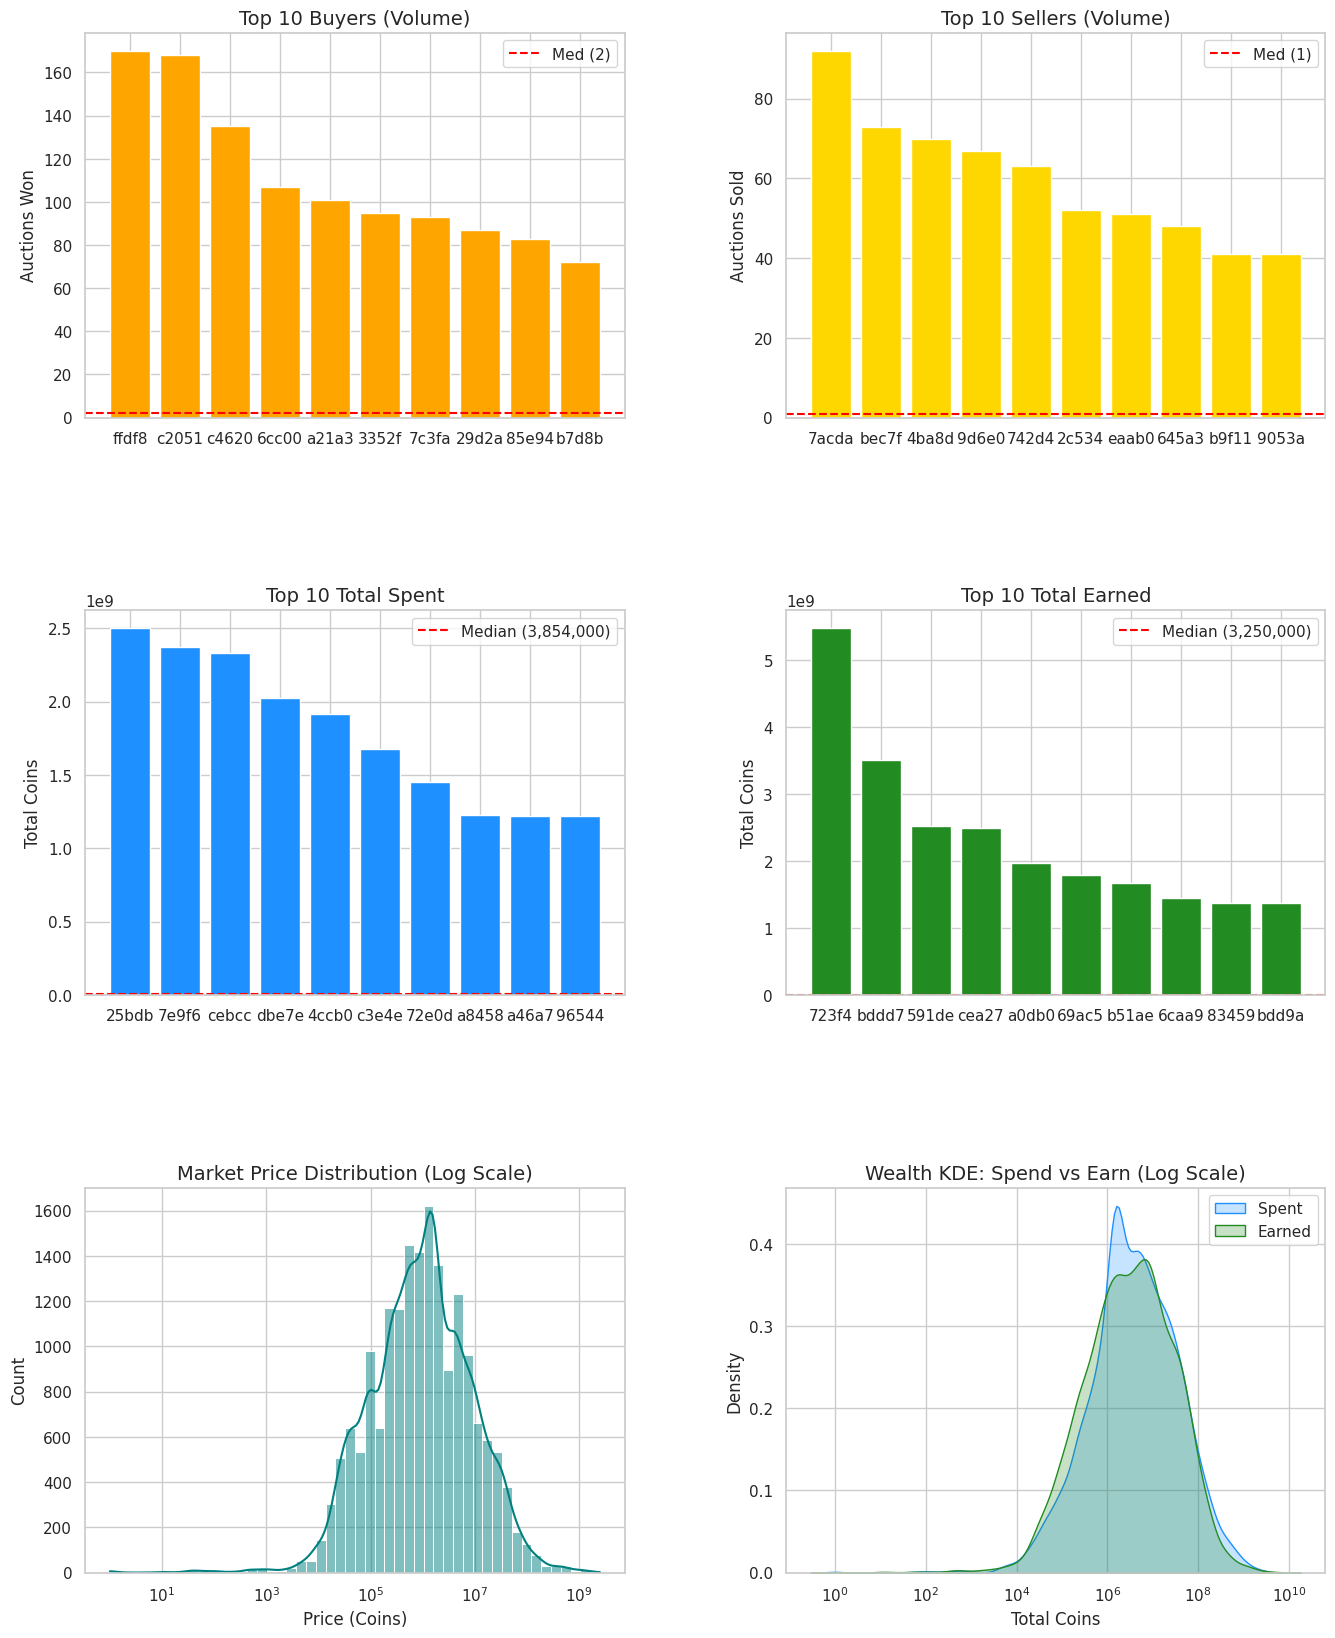

In [20]:
# --- 1. Setup Style & Canvas ---
sns.set_theme(style="whitegrid")
# Using a 3x2 grid to fit all 6 visualizations
fig, axes = plt.subplots(3, 2, figsize=(16, 20))
plt.subplots_adjust(hspace=0.5, wspace=0.3)

# --- ROW 1: VOLUME (TRANSACTION COUNTS) ---

# 1. Top 10 Buyers (Last 5 Chars)
buyer_counts = df['buyer_uuid'].value_counts().head(10)
short_buyer_ids = [str(x)[-5:] for x in buyer_counts.index]
axes[0, 0].bar(short_buyer_ids, buyer_counts.values, color='orange')
median_purchases = df['buyer_uuid'].value_counts().median()
axes[0, 0].axhline(y=median_purchases, color='red', linestyle='--', label=f'Med ({median_purchases:,.0f})')
axes[0, 0].set_title('Top 10 Buyers (Volume)', fontsize=14)
axes[0, 0].set_ylabel('Auctions Won')
axes[0, 0].legend()

# 2. Top 10 Sellers (Last 5 Chars)
seller_counts = df['seller_uuid'].value_counts().head(10)
short_seller_ids = [str(x)[-5:] for x in seller_counts.index]
axes[0, 1].bar(short_seller_ids, seller_counts.values, color='gold')
median_sales = df['seller_uuid'].value_counts().median()
axes[0, 1].axhline(y=median_sales, color='red', linestyle='--', label=f'Med ({median_sales:,.0f})')
axes[0, 1].set_title('Top 10 Sellers (Volume)', fontsize=14)
axes[0, 1].set_ylabel('Auctions Sold')
axes[0, 1].legend()

# --- ROW 2: VALUE (COIN FLOW) ---

# 3. Top 10 Spenders (Last 5 Chars)
spent_per_player = df.groupby('buyer_uuid')['final_price'].sum().sort_values(ascending=False).head(10)
short_spender_ids = [str(x)[-5:] for x in spent_per_player.index]
axes[1, 0].bar(short_spender_ids, spent_per_player.values, color='dodgerblue')
median_spent = df.groupby('buyer_uuid')['final_price'].sum().median()
# Added value to median in legend
axes[1, 0].axhline(y=median_spent, color='red', linestyle='--', label=f'Median ({median_spent:,.0f})')
axes[1, 0].set_title('Top 10 Total Spent', fontsize=14)
axes[1, 0].set_ylabel('Total Coins')
axes[1, 0].legend()

# 4. Top 10 Earners (Last 5 Chars)
earned_per_player = df.groupby('seller_uuid')['final_price'].sum().sort_values(ascending=False).head(10)
short_earner_ids = [str(x)[-5:] for x in earned_per_player.index]
axes[1, 1].bar(short_earner_ids, earned_per_player.values, color='forestgreen')
median_earned = df.groupby('seller_uuid')['final_price'].sum().median()
# Added value to median in legend
axes[1, 1].axhline(y=median_earned, color='red', linestyle='--', label=f'Median ({median_earned:,.0f})')
axes[1, 1].set_title('Top 10 Total Earned', fontsize=14)
axes[1, 1].set_ylabel('Total Coins')
axes[1, 1].legend()

# --- ROW 3: GLOBAL DISTRIBUTIONS ---

# 5. Price Distribution (Log Scale)
sns.histplot(df['final_price'], bins=50, kde=True, ax=axes[2, 0], log_scale=True, color='teal')
axes[2, 0].set_title('Market Price Distribution (Log Scale)', fontsize=14)
axes[2, 0].set_xlabel('Price (Coins)')

# 6. Money Spent vs Earned Distribution
full_spent = df.groupby('buyer_uuid')['final_price'].sum()
full_earned = df.groupby('seller_uuid')['final_price'].sum()
sns.kdeplot(full_spent, ax=axes[2, 1], log_scale=True, label='Spent', fill=True, color='dodgerblue')
sns.kdeplot(full_earned, ax=axes[2, 1], log_scale=True, label='Earned', fill=True, color='forestgreen')
axes[2, 1].set_title('Wealth KDE: Spend vs Earn (Log Scale)', fontsize=14)
axes[2, 1].set_xlabel('Total Coins')
axes[2, 1].legend()

plt.show()

In [ ]:
sample_row = df.sample(1).iloc[0]

# 2. Pass the specific string to the function
# (No KeyError because sample_row is a Series where 'item_bytes' is a valid key)
decoded_nbt = decode_nbt(sample_row['item_bytes'])

for item in decoded_nbt:
    print(item)

print(decode_and_print_all(sample_row['item_bytes']))

{TAG_Short('id'): 302, TAG_Byte('Count'): 1, TAG_Compound('tag'): {4 Entries}, TAG_Short('Damage'): 0}
